# Calculating statistical differences between segmentation accuracy metrics for different segmentation methods

### For this example specifically, I have calculated the difference in Fscore, Precision, Recall, and the aggregated Jaccard Index (AJI) for the default cellpose SAM model, xenium segmentation, and a custom trained cellpose SAM model, using my test images from the custom training as 'Ground Truth' labels

In [2]:
#loading data
import pandas as pd

#default metrics
default = pd.read_csv(r"D:\Dom\Psoriasis project\4th year data\cellpose training\Crops_Round2\Model Performance\Cross-Sectional\Default_CellposeSAM_metrics.csv")

#Xenium metrics
xen = pd.read_csv(r"D:\Dom\Psoriasis project\4th year data\cellpose training\Crops_Round2\Model Performance\Cross-Sectional\Xenium_Proprietary_metrics.csv")

#custom trained model metrics
v8 = pd.read_csv(r"D:\Dom\Psoriasis project\4th year data\cellpose training\Crops_Round2\Model Performance\Cross-Sectional\Mouse_Ear_Skin_V8_metrics.csv")

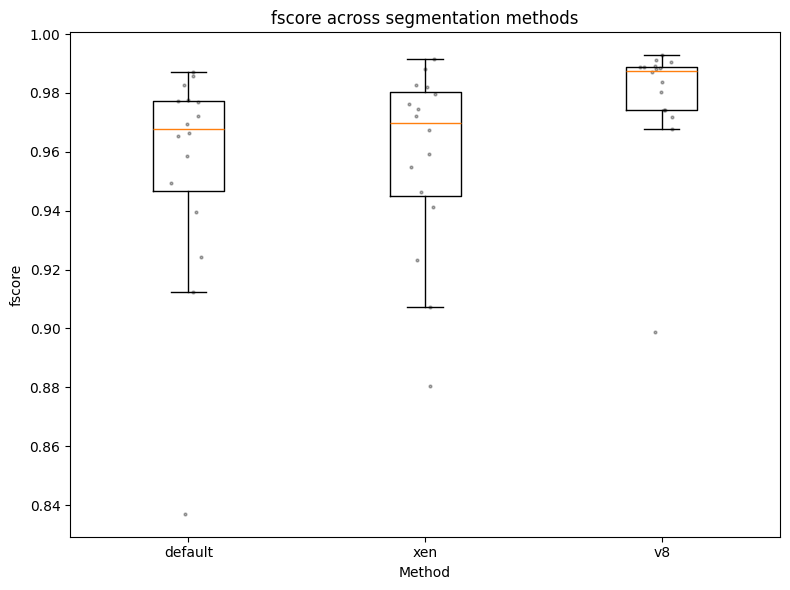

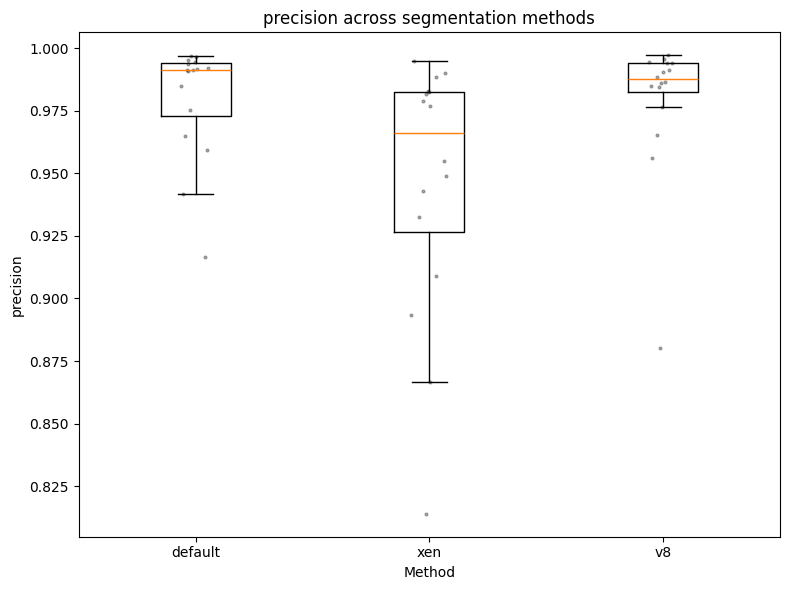

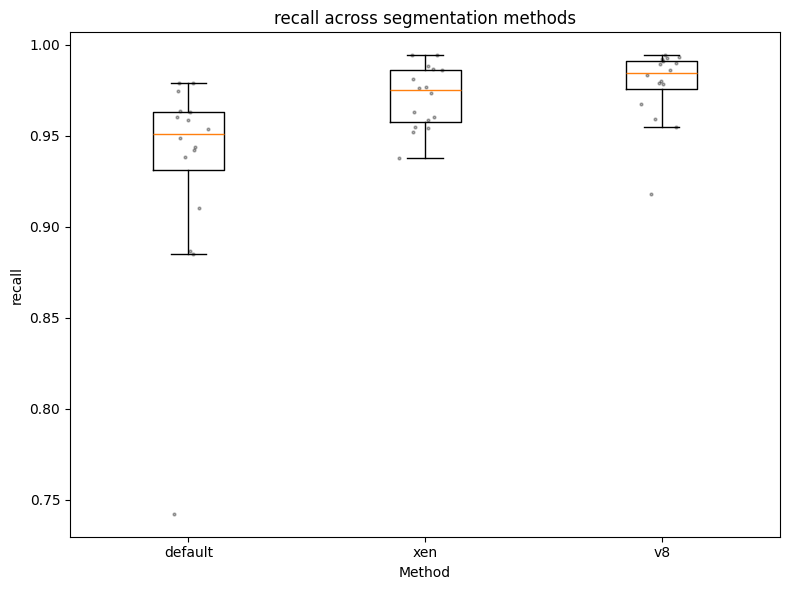

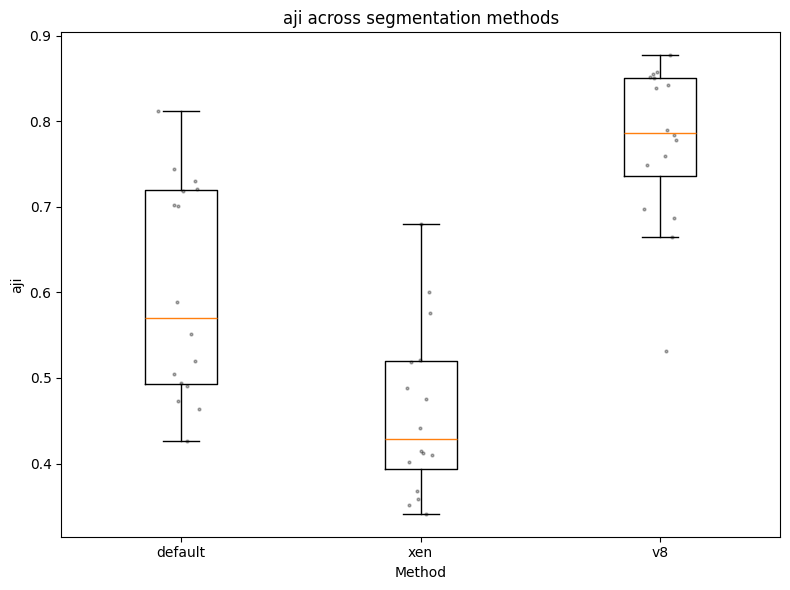

In [29]:
import matplotlib.pyplot as plt
import numpy as np

#Plotting the F scores per image per run
def plot_metric_stats(metric_choice, segmentation_methods):
    """ 
    Plot boxplots comparing a metric of choice among several segmentation methods, with a statistical test performed for each (which one?)

    *inputs*
    metric_choice = one of ["precision", "recall", "fscore", "aji"]

    segmentation_methods = {'method_name':data.frame(method)} dict of dataframes containing given metric values for each image in the test set
    """
    data = []

    for method in segmentation_methods.values():
        #get a list of metric data for each method (list of lists)
        data.append(method[metric_choice])


    fig, ax = plt.subplots(figsize=(8, 6))

    ax.boxplot(data, tick_labels=[method for method in segmentation_methods.keys()], showfliers=False)

    for i, group in enumerate(data, start=1):
        x = np.random.normal(i, 0.04, size=len(group))  # jitter around the box's x position
        ax.plot(x, group, 'k.', alpha=0.3, markersize=4)

    ax.set_title(f"{metric_choice} across segmentation methods")
    ax.set_xlabel("Method")
    ax.set_ylabel(f"{metric_choice}")

    plt.tight_layout()

    plt.show()

plot_metric_stats('fscore', {'default':default, 'xen':xen, 'v8':v8})
plot_metric_stats('precision', {'default':default, 'xen':xen, 'v8':v8})
plot_metric_stats('recall', {'default':default, 'xen':xen, 'v8':v8})
plot_metric_stats('aji', {'default':default, 'xen':xen, 'v8':v8})

In [63]:
#Two sample T-test. ANOVA not suitable as variances are different. Assuming normality of F-scores (possibly shaky as value is 0-1 bounded)

from scipy import stats

segmentation_methods= {'default':default, 'xen':xen, 'v8':v8}
sample_sizes = {}
for key, df in segmentation_methods.items():
    sample_size = len(df['image'])
    sample_sizes[key] = sample_size


#Two-sample T-test between xen and V8 
N1, N2, = sample_sizes['default'], sample_sizes['v8']

#degrees of freedom
dof = min(N1,N2) -1

#data 
metric_choice = 'precision'
data_x = segmentation_methods['xen'][metric_choice]
data_y = segmentation_methods['v8'][metric_choice]

#ttest
t_stat, p_val = stats.ttest_ind(data_x, data_y)
print("t-statistic = " + str(t_stat))  
print("p-value = " + str(p_val))

t-statistic = -2.2242168128993223
p-value = 0.03380628268302774


### Add in significance on the graph
#### I have used a two-sample t-test in this case, as I only wish to compare the significance between the Xenium and Custom Trained models, thus am not carrying out multiple comparisons. Additionally, if i did wish to compare all methods, ANOVA would not be suitable as the within group variances are different for each group. 

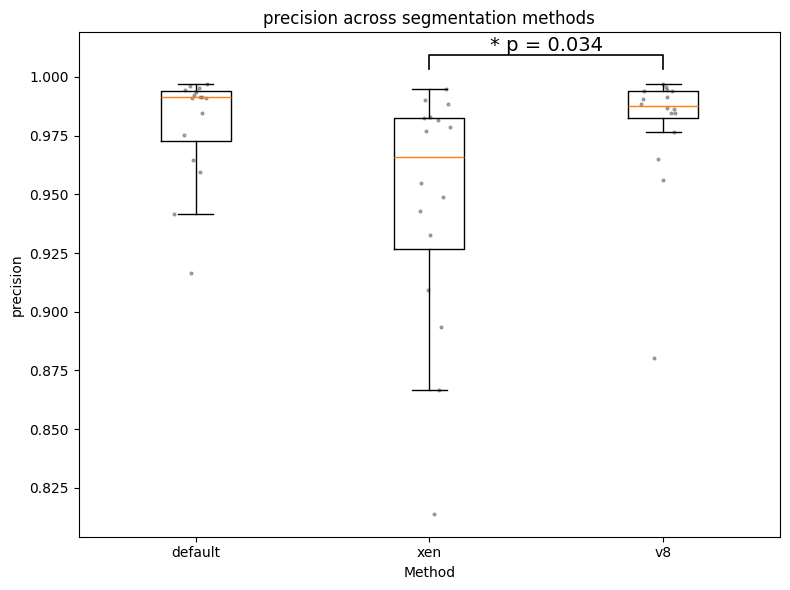

In [65]:
#attempt at adding in significance braces (assuming you know significance prior)

import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

def add_significance_brace(ax, x1, x2, y, h, text): #thanks claude
    """
    Draw a significance brace between two boxplots.
    
    x1, x2: x-positions of the two groups (1-indexed)
    y:      bottom of the brace (usually just above the tallest box)
    h:      height of the brace tick marks
    text:   annotation text (e.g. '*')
    """
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c='black')
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', fontsize=14)


def plot_metric_stats_sig(metric_choice, segmentation_methods, p_value):
    data = []
    for method in segmentation_methods.values():
        data.append(method[metric_choice])

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.boxplot(data, tick_labels=list(segmentation_methods.keys()), showfliers=False)

    for i, group in enumerate(data, start=1):
        x = np.random.normal(i, 0.04, size=len(group))
        ax.plot(x, group, 'k.', alpha=0.3, markersize=4)

    ax.set_title(f"{metric_choice} across segmentation methods")
    ax.set_xlabel("Method")
    ax.set_ylabel(f"{metric_choice}")

    # --- Significance brace between 'xen' (pos 2) and 'v8' (pos 3) --- #change if you want to alter what you have tested for significance
    method_names = list(segmentation_methods.keys())
    x1 = method_names.index('xen') + 1  # +1 because matplotlib boxplots are 1-indexed
    x2 = method_names.index('v8') + 1

    # y position: just above the highest data point in either group
    all_vals = np.concatenate([data[x1-1], data[x2-1]])
    y_max = np.max(all_vals)
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    y     = y_max + y_range * 0.03   # small gap above the data
    h     = y_range * 0.03           # height of the tick marks

    add_significance_brace(ax, x1, x2, y, h, f'* p = {p_value:.2g}')

    plt.tight_layout()
    plt.show()



plot_metric_stats_sig('precision', {'default':default, 'xen':xen, 'v8':v8}, p_value = p_val)
